import liabraries

In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time Series
from statsmodels.tsa.seasonal import seasonal_decompose

# Anomaly Detection
from scipy import stats

# Scaling
from sklearn.preprocessing import MinMaxScaler

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

load dataset

In [4]:
# Load Dataset
import pandas as pd
df = pd.read_csv('/content/monthly_milk_production.csv')

In [5]:
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


Identify the Business Problem
Business Problem

Milk production varies throughout the year because of weather conditions, cattle health, seasonal demand, and farming practices. Without accurate forecasting, dairy companies may experience inventory shortages, excess storage costs, or inefficient workforce planning.

Define the Objective
Objective

The objective is to develop a deep learning forecasting model capable of predicting future monthly milk production. Accurate forecasts will help dairy businesses optimize inventory, improve supply chain planning, reduce waste, and make better operational decisions.

dataset overview

In [6]:
print("Shape :", df.shape)

print("\nColumns")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nStatistical Summary")
df.describe()

Shape : (168, 2)

Columns
Index(['Date', 'Production'], dtype='object')

Data Types
Date          object
Production     int64
dtype: object

Statistical Summary


,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


convert data column

In [7]:
# Rename columns if necessary
df.columns=['Month','Milk Production']

# Convert Month column to datetime
df['Month']=pd.to_datetime(df['Month'])

# Set Month as index
df.set_index('Month', inplace=True)

df.head()

,Milk Production
Month,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


exploratory data anlysis (EDA)

trend visualization

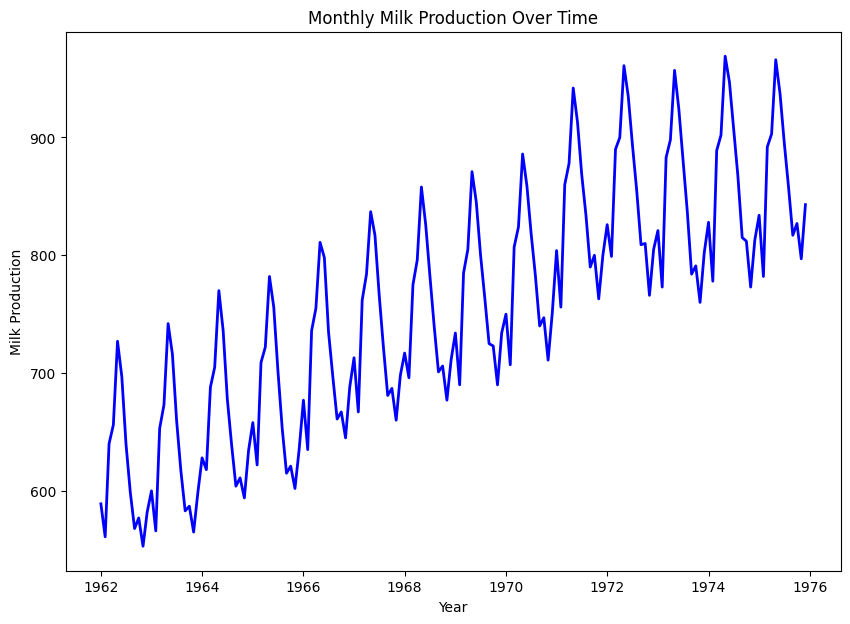

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

plt.plot(df.index,
         df['Milk Production'],
         color='blue',
         linewidth=2)

plt.title("Monthly Milk Production Over Time")
plt.xlabel("Year")
plt.ylabel("Milk Production")
plt.show()

seasonality visualization

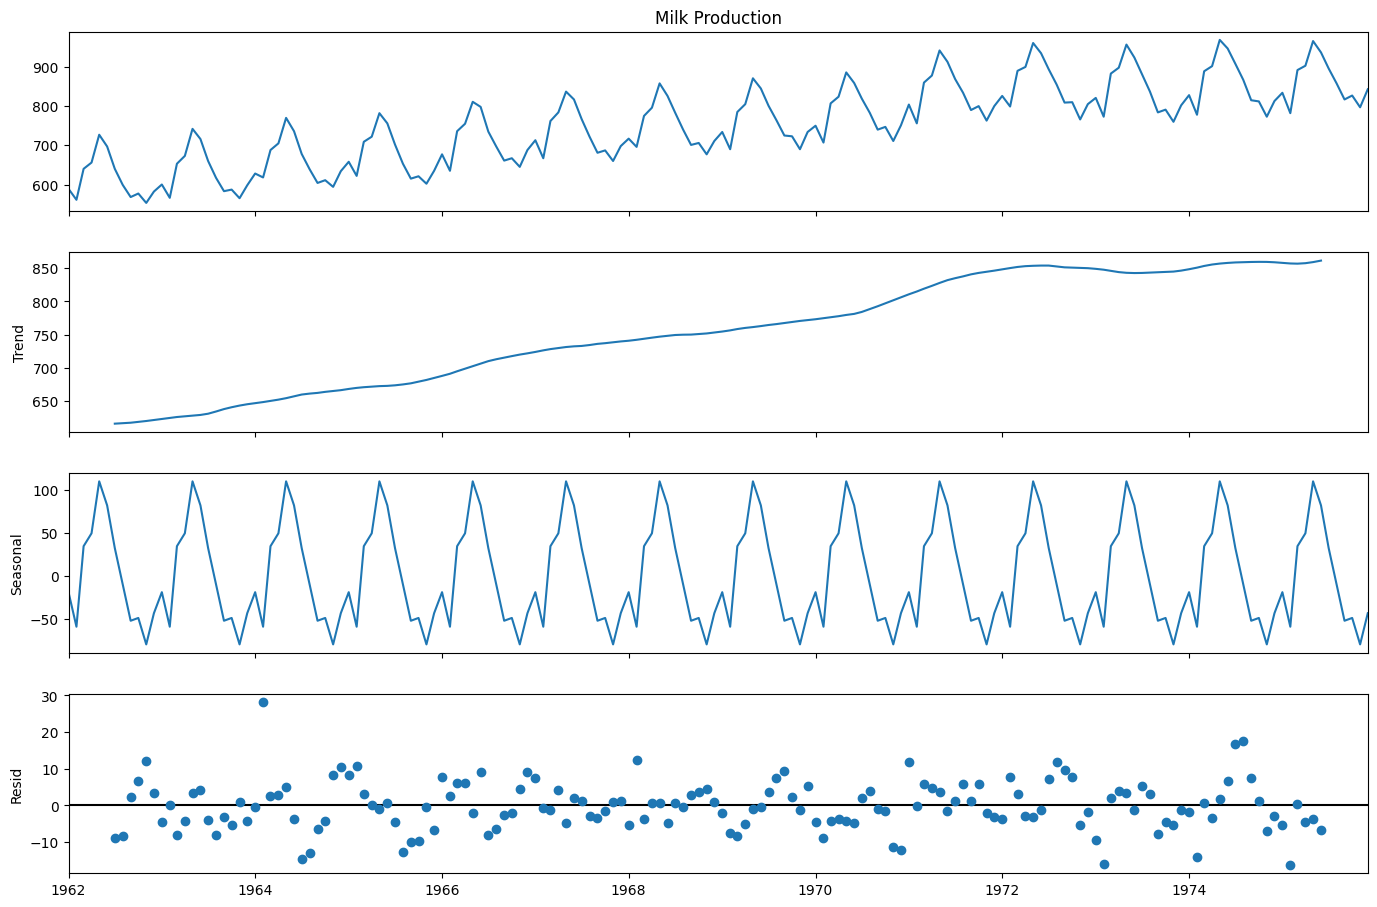

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Milk Production'],
                                   model='additive',
                                   period=12)

fig = decomposition.plot()
fig.set_size_inches(15,10)
plt.show()

anomaly detection

In [15]:
import numpy as np
from scipy import stats
df['Z_score'] = np.abs(stats.zscore(df['Milk Production']))
anomalies = df[df['Z_score']>3]
print("Number of anomalies :", len(anomalies))
anomalies

Number of anomalies : 0


,Milk Production,Z_score
Month,,


plot anomalies


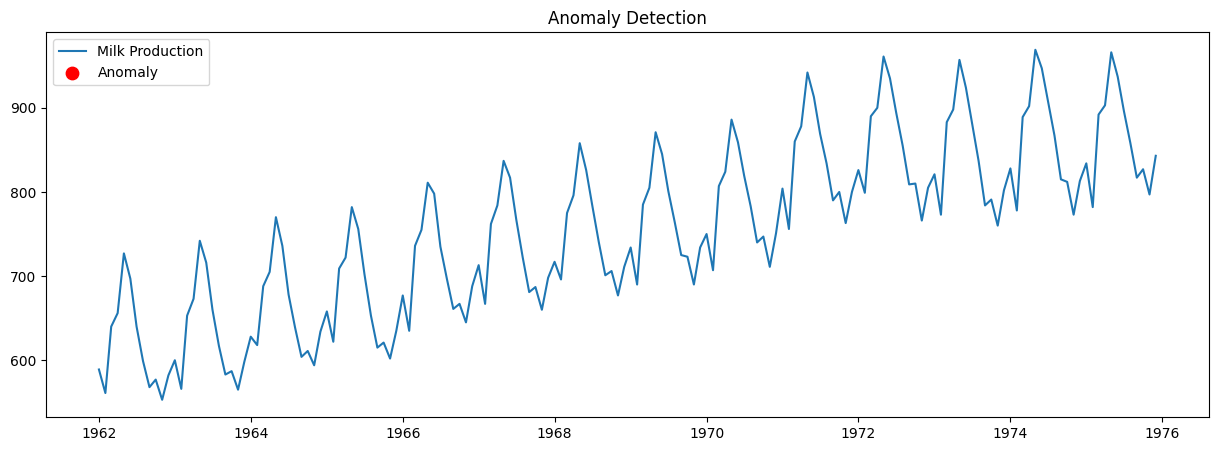

In [16]:
plt.figure(figsize=(15,5))

plt.plot(df.index,
         df['Milk Production'],
         label='Milk Production')

plt.scatter(anomalies.index,
            anomalies['Milk Production'],
            color='red',
            label='Anomaly',
            s=80)

plt.legend()
plt.title("Anomaly Detection")
plt.show()

missing value check

In [17]:
print(df.isnull().sum())

Milk Production    0
Z_score            0
dtype: int64


visualization

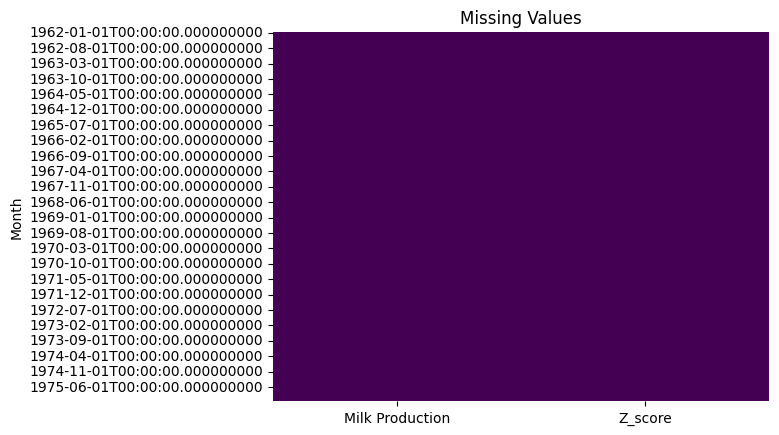

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis')

plt.title("Missing Values")
plt.show()

outlier detection

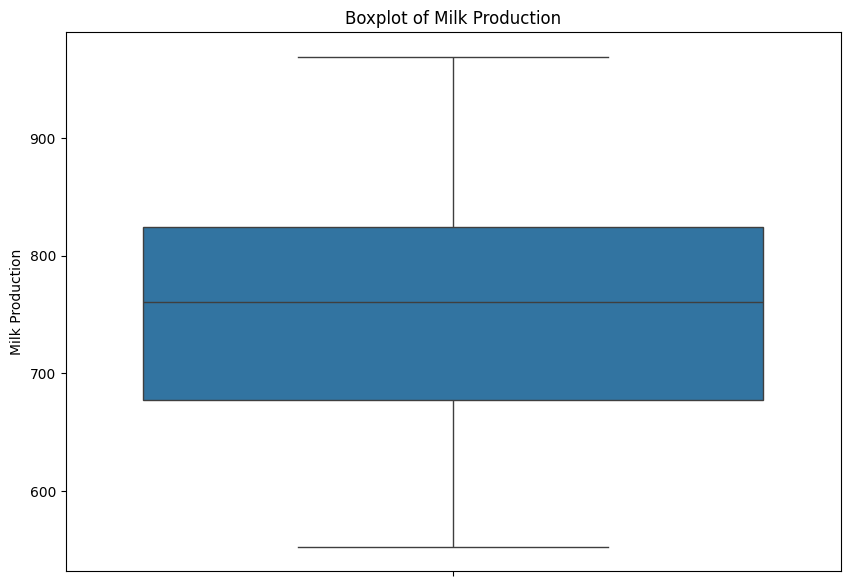

In [20]:
plt.figure(figsize=(10,7))

sns.boxplot(y=df['Milk Production'])

plt.title("Boxplot of Milk Production")
plt.show()

data normalization

In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['Scaled Production'] = scaler.fit_transform(df[['Milk Production']])

df.head()

,Milk Production,Z_score,Scaled Production
Month,,,
1962-01-01,589,1.626188,0.086538
1962-02-01,561,1.900967,0.019231
1962-03-01,640,1.125696,0.209135
1962-04-01,656,0.968679,0.247596
1962-05-01,727,0.271917,0.418269


visualize normaliazed data

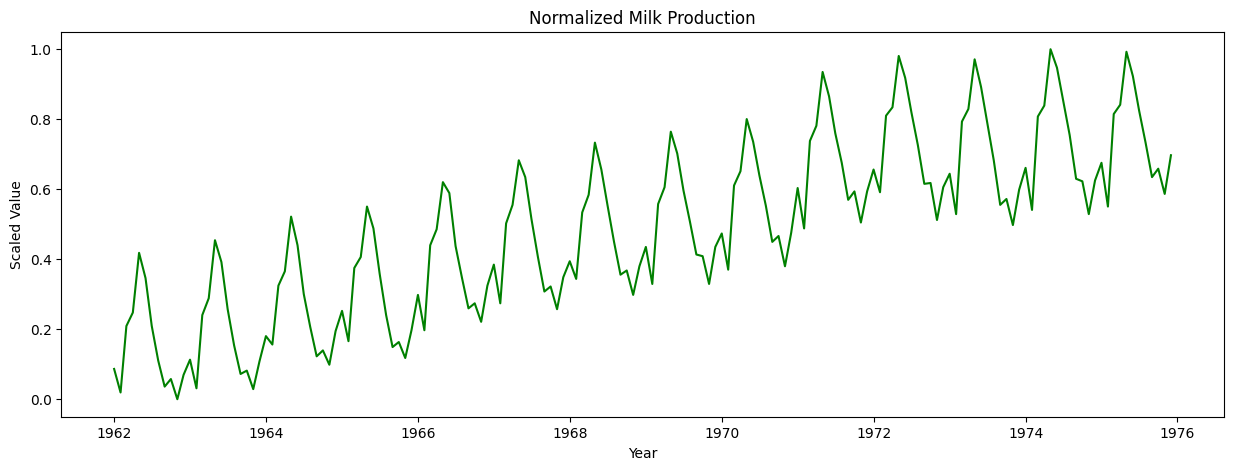

In [23]:
plt.figure(figsize=(15,5))

plt.plot(df.index,
         df['Scaled Production'],
         color='green')

plt.title("Normalized Milk Production")
plt.xlabel("Year")
plt.ylabel("Scaled Value")
plt.show()

final dataset

In [24]:
df.head()

,Milk Production,Z_score,Scaled Production
Month,,,
1962-01-01,589,1.626188,0.086538
1962-02-01,561,1.900967,0.019231
1962-03-01,640,1.125696,0.209135
1962-04-01,656,0.968679,0.247596
1962-05-01,727,0.271917,0.418269


importing libraries

In [25]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import GRU
from tensorflow.keras.callbacks import EarlyStopping

print(tf.__version__)

2.20.0


create sliding windows

In [26]:
window_size = 12

data = df['Scaled Production'].values

X = []
y = []

for i in range(len(data)-window_size):
    X.append(data[i:i+window_size])
    y.append(data[i+window_size])

X = np.array(X)
y = np.array(y)

print("Input Shape :", X.shape)
print("Output Shape :", y.shape)

Input Shape : (156, 12)
Output Shape : (156,)


train validation test split

In [27]:
train_size = int(len(X)*0.70)
val_size = int(len(X)*0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(109, 12)
(23, 12)
(24, 12)


reshape of RNN

In [28]:
X_train = X_train.reshape((X_train.shape[0],
                           X_train.shape[1],
                           1))

X_val = X_val.reshape((X_val.shape[0],
                       X_val.shape[1],
                       1))

X_test = X_test.reshape((X_test.shape[0],
                         X_test.shape[1],
                         1))

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(109, 12, 1)
(23, 12, 1)
(24, 12, 1)


early stopping

In [29]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model 1

In [30]:
rnn_model = Sequential()

rnn_model.add(SimpleRNN(
    64,
    activation='tanh',
    input_shape=(window_size,1)
))

rnn_model.add(Dense(1))

rnn_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

rnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

train RNN

In [31]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0756 - mae: 0.2189 - val_loss: 0.0341 - val_mae: 0.1499
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0174 - mae: 0.1081 - val_loss: 0.0258 - val_mae: 0.1303
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0087 - mae: 0.0785 - val_loss: 0.0121 - val_mae: 0.0916
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0057 - mae: 0.0610 - val_loss: 0.0130 - val_mae: 0.0989
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0044 - mae: 0.0543 - val_loss: 0.0065 - val_mae: 0.0669
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0031 - mae: 0.0415 - val_loss: 0.0053 - val_mae: 0.0584
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0025 - mae: 0.0415 - val_loss: 0.0063 - val_mae: 0.0639
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0023 - mae: 0.0386 - val_loss: 0.0048 - val_mae: 0.0572
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0022 - mae: 

model 2

In [32]:
lstm_model = Sequential()

lstm_model.add(LSTM(
    64,
    activation='tanh',
    input_shape=(window_size,1)
))

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

train LSTM

In [33]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.2169 - mae: 0.4126 - val_loss: 0.3110 - val_mae: 0.5353
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0724 - mae: 0.2216 - val_loss: 0.0378 - val_mae: 0.1518
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0367 - mae: 0.1689 - val_loss: 0.0441 - val_mae: 0.1748
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0313 - mae: 0.1565 - val_loss: 0.0345 - val_mae: 0.1506
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0302 - mae: 0.1434 - val_loss: 0.0525 - val_mae: 0.1756
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0289 - mae: 0.1380 - val_loss: 0.0336 - val_mae: 0.1489
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0268 - mae: 0.1433 - val_loss: 0.0273 - val_mae: 0.1479
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0264 - mae: 0.1428 - val_loss: 0.0300 - val_mae: 0.1466
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0257 - mae: 

model 3

In [34]:
gru_model = Sequential()

gru_model.add(GRU(
    64,
    activation='tanh',
    input_shape=(window_size,1)
))

gru_model.add(Dense(1))

gru_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

train GRU

In [35]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.1272 - mae: 0.2986 - val_loss: 0.1313 - val_mae: 0.3310
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0320 - mae: 0.1417 - val_loss: 0.0244 - val_mae: 0.1326
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0325 - mae: 0.1542 - val_loss: 0.0230 - val_mae: 0.1336
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0267 - mae: 0.1406 - val_loss: 0.0323 - val_mae: 0.1387
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0223 - mae: 0.1253 - val_loss: 0.0433 - val_mae: 0.1613
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0229 - mae: 0.1248 - val_loss: 0.0398 - val_mae: 0.1538
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0214 - mae: 0.1228 - val_loss: 0.0298 - val_mae: 0.1324
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0204 - mae: 0.1211 - val_loss: 0.0264 - val_mae: 0.1262
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0201 - mae: 

plot training history RNN

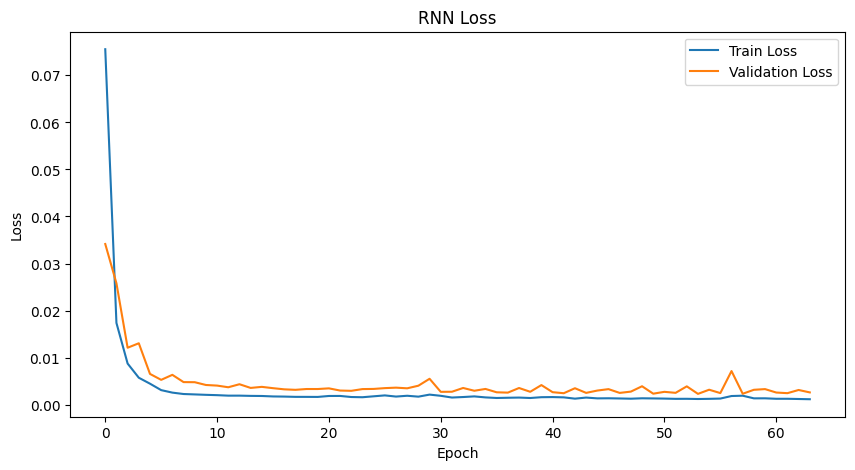

In [36]:
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['loss'],label='Train Loss')
plt.plot(history_rnn.history['val_loss'],label='Validation Loss')

plt.title("RNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

LSTM

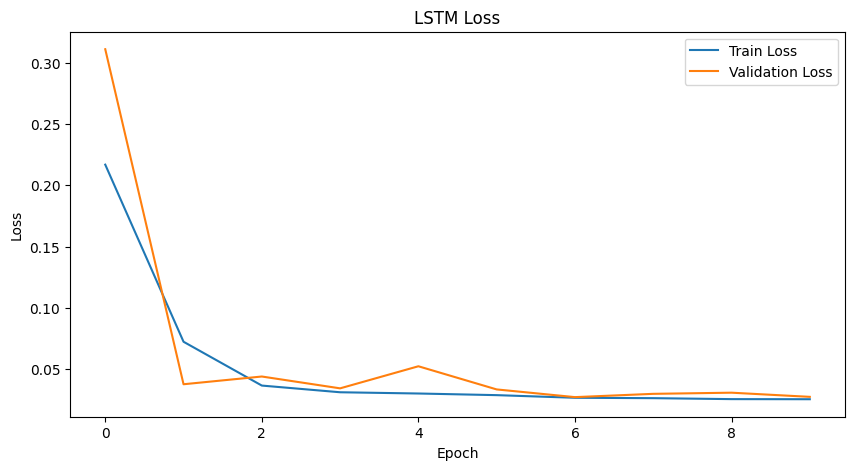

In [37]:
plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['loss'],label='Train Loss')
plt.plot(history_lstm.history['val_loss'],label='Validation Loss')

plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

GRU

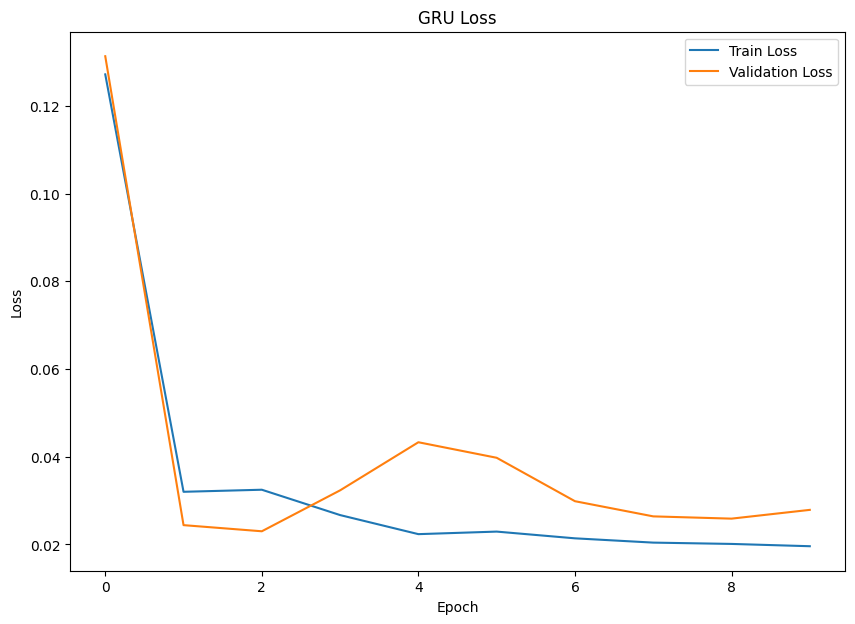

In [39]:
plt.figure(figsize=(10,7))

plt.plot(history_gru.history['loss'],label='Train Loss')
plt.plot(history_gru.history['val_loss'],label='Validation Loss')

plt.title("GRU Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

tuned LSTM model

In [40]:
from tensorflow.keras.layers import Dropout

tuned_lstm = Sequential()

tuned_lstm.add(LSTM(
    128,
    activation='tanh',
    return_sequences=True,
    input_shape=(window_size,1)
))
tuned_lstm.add(Dropout(0.2))

tuned_lstm.add(LSTM(64))
tuned_lstm.add(Dropout(0.2))

tuned_lstm.add(Dense(1))

tuned_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

tuned_lstm.summary()

history_tuned = tuned_lstm.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 12, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,033 (453.25 KB)

 Trainable params: 116,033 (453.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - loss: 0.0769 - mae: 0.2095 - val_loss: 0.0835 - val_mae: 0.2457
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0334 - mae: 0.1544 - val_loss: 0.0527 - val_mae: 0.1772
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0369 - mae: 0.1519 - val_loss: 0.0354 - val_mae: 0.1480
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0275 - mae: 0.1394 - val_loss: 0.0278 - val_mae: 0.1502
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0278 - mae: 0.1415 - val_loss: 0.0366 - val_mae: 0.1478
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0237 - mae: 0.1295 - val_loss: 0.0260 - val_mae: 0.1424
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0295 - mae: 0.1484 - val_loss: 0.0275 - val_mae: 0.1417
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0274 - mae: 0.1376 - val_loss: 0.0394 - val_mae: 0.1511
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0269 - mae: 

import Evaluation metrics

In [41]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

import math

make predictions

RNN predictions

In [44]:
rnn_pred = rnn_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


LSTM  predictions

In [45]:
lstm_pred = lstm_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step


GRU predictions

In [46]:
gru_pred = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step


In [47]:
gru_pred = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


convert backl to original scale

In [48]:
# Actual Values
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# Predictions
rnn_pred_actual = scaler.inverse_transform(rnn_pred)
lstm_pred_actual = scaler.inverse_transform(lstm_pred)
gru_pred_actual = scaler.inverse_transform(gru_pred)

calculate RMSE,MAE, and MAPE

RNN

In [50]:
rnn_rmse = math.sqrt(mean_squared_error(y_test_actual, rnn_pred_actual))
rnn_mae = mean_absolute_error(y_test_actual, rnn_pred_actual)
rnn_mape = mean_absolute_percentage_error(y_test_actual, rnn_pred_actual) * 100

print("RNN Results")
print("RMSE :", rnn_rmse)
print("MAE  :", rnn_mae)
print("MAPE :", rnn_mape)

RNN Results
RMSE : 13.846164916020648
MAE  : 11.243639628092438
MAPE : 1.2968353131637018


LSTM

In [52]:
lstm_rmse = math.sqrt(mean_squared_error(y_test_actual, lstm_pred_actual))
lstm_mae = mean_absolute_error(y_test_actual, lstm_pred_actual)
lstm_mape = mean_absolute_percentage_error(y_test_actual, lstm_pred_actual) * 100

print("LSTM Results")
print("RMSE :", lstm_rmse)
print("MAE  :", lstm_mae)
print("MAPE :", lstm_mape)

LSTM Results
RMSE : 241.07010379112958
MAE  : 233.00594329833984
MAPE : 26.71913884112977


GRU

In [53]:
gru_rmse = math.sqrt(mean_squared_error(y_test_actual, gru_pred_actual))
gru_mae = mean_absolute_error(y_test_actual, gru_pred_actual)
gru_mape = mean_absolute_percentage_error(y_test_actual, gru_pred_actual) * 100

print("GRU Results")
print("RMSE :", gru_rmse)
print("MAE  :", gru_mae)
print("MAPE :", gru_mape)

GRU Results
RMSE : 158.0752623303072
MAE  : 146.87259674072266
MAPE : 16.70158621437715


predictions vs actual plots

 RNN

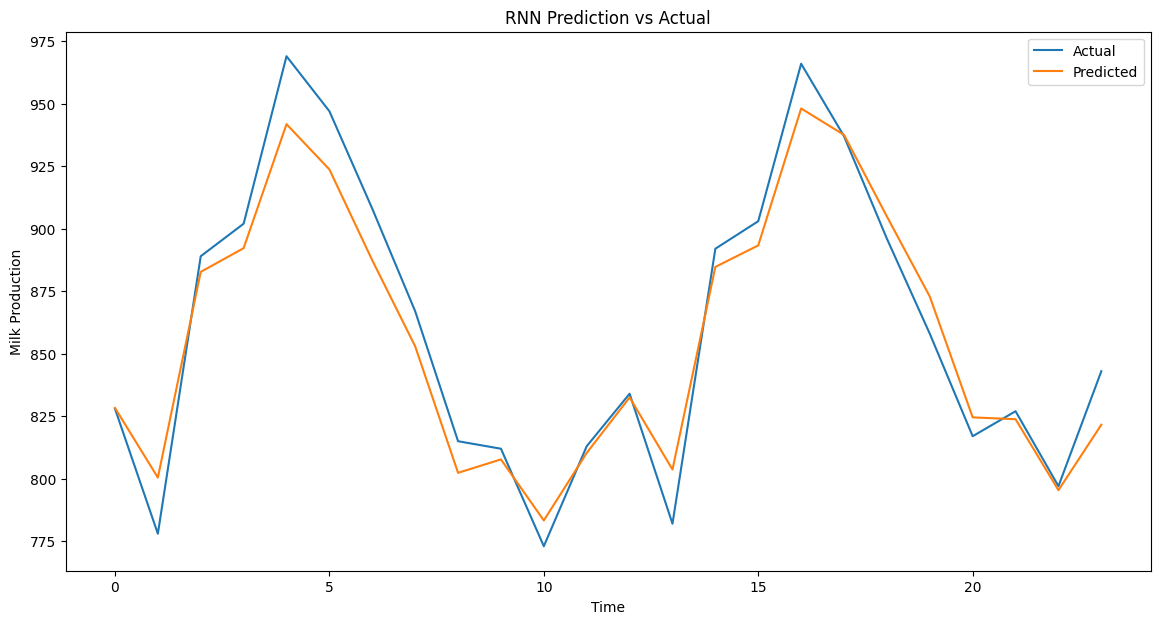

In [57]:
plt.figure(figsize=(14,7))

plt.plot(y_test_actual,label='Actual')
plt.plot(rnn_pred_actual,label='Predicted')

plt.title("RNN Prediction vs Actual")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

LSTM

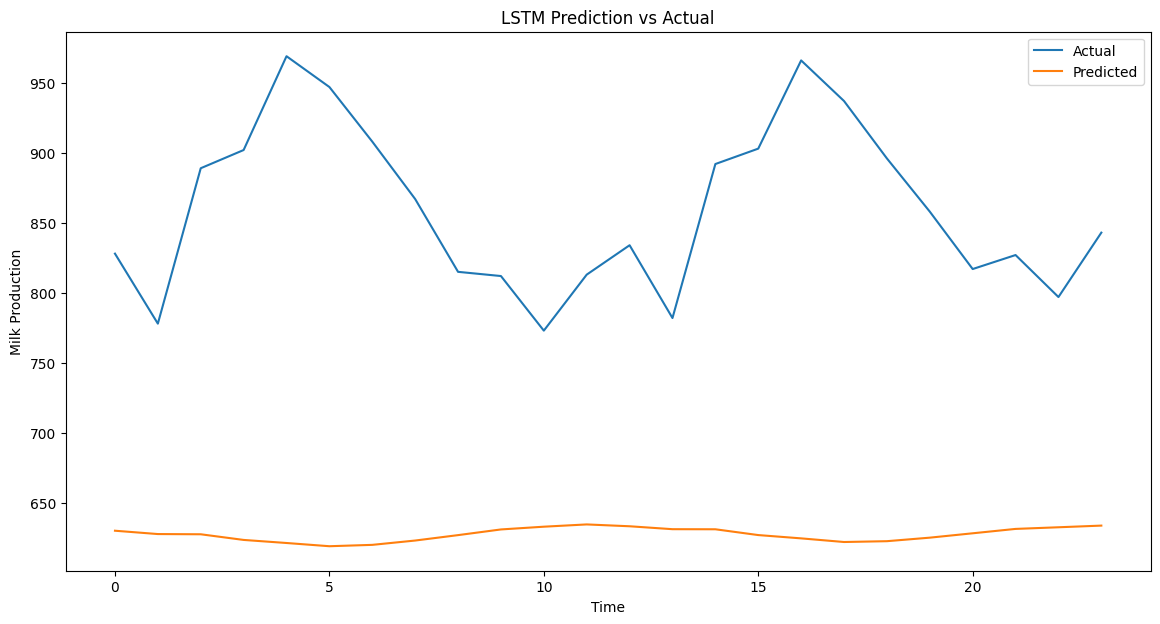

In [56]:
plt.figure(figsize=(14,7))

plt.plot(y_test_actual,label='Actual')
plt.plot(lstm_pred_actual,label='Predicted')

plt.title("LSTM Prediction vs Actual")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

GRU

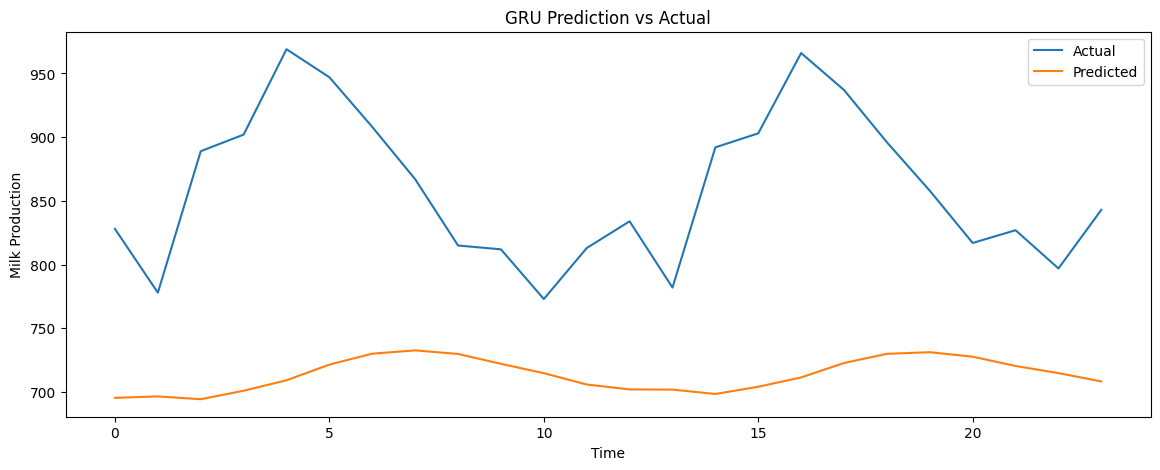

In [58]:
plt.figure(figsize=(14,5))

plt.plot(y_test_actual,label='Actual')
plt.plot(gru_pred_actual,label='Predicted')

plt.title("GRU Prediction vs Actual")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

model comparison

In [59]:
comparison = pd.DataFrame({

    'Model':['RNN','LSTM','GRU'],
    'RMSE':[rnn_rmse,lstm_rmse,gru_rmse],
    'MAE':[rnn_mae,lstm_mae,gru_mae],
    'MAPE':[rnn_mape,lstm_mape,gru_mape]

})

comparison

,Model,RMSE,MAE,MAPE
0,RNN,13.846165,11.243640,1.296835
1,LSTM,241.070104,233.005943,26.719139
2,GRU,158.075262,146.872597,16.701586


best model

In [60]:
best_model = comparison.loc[comparison['RMSE'].idxmin()]

print("Best Model")
print(best_model)

Best Model
Model          RNN
RMSE     13.846165
MAE       11.24364
MAPE      1.296835
Name: 0, dtype: object


model comparison graph

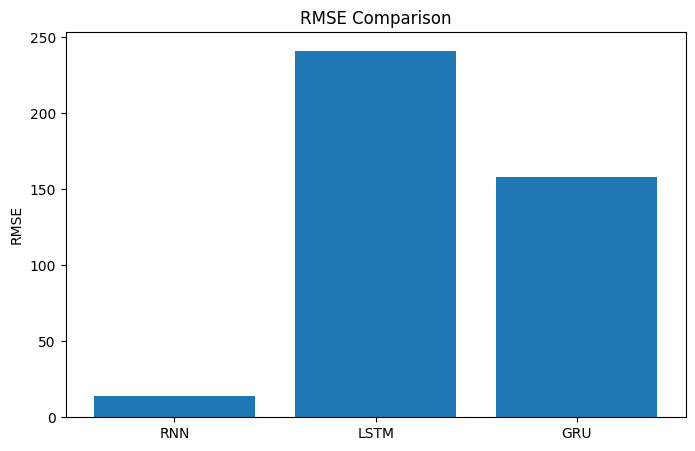

In [61]:
plt.figure(figsize=(8,5))

plt.bar(comparison['Model'],
        comparison['RMSE'])

plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

forecast next 12 months

In [62]:
future_input = data[-window_size:]
future_input = future_input.reshape(1, window_size, 1)

future_predictions = []

for i in range(12):

    pred = lstm_model.predict(future_input, verbose=0)

    future_predictions.append(pred[0][0])

    future_input = np.append(future_input[:,1:,:],
                             [[[pred[0][0]]]],
                             axis=1)

convert forecast to original scale

In [63]:
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

future_predictions

array([[632.3888 ],
       [635.3304 ],
       [634.59   ],
       [630.3889 ],
       [625.097  ],
       [618.8889 ],
       [613.1871 ],
       [608.2279 ],
       [603.9944 ],
       [600.4909 ],
       [597.18274],
       [594.4859 ]], dtype=float32)

generate future dates

In [64]:
last_date = df.index[-1]

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

plot forecast

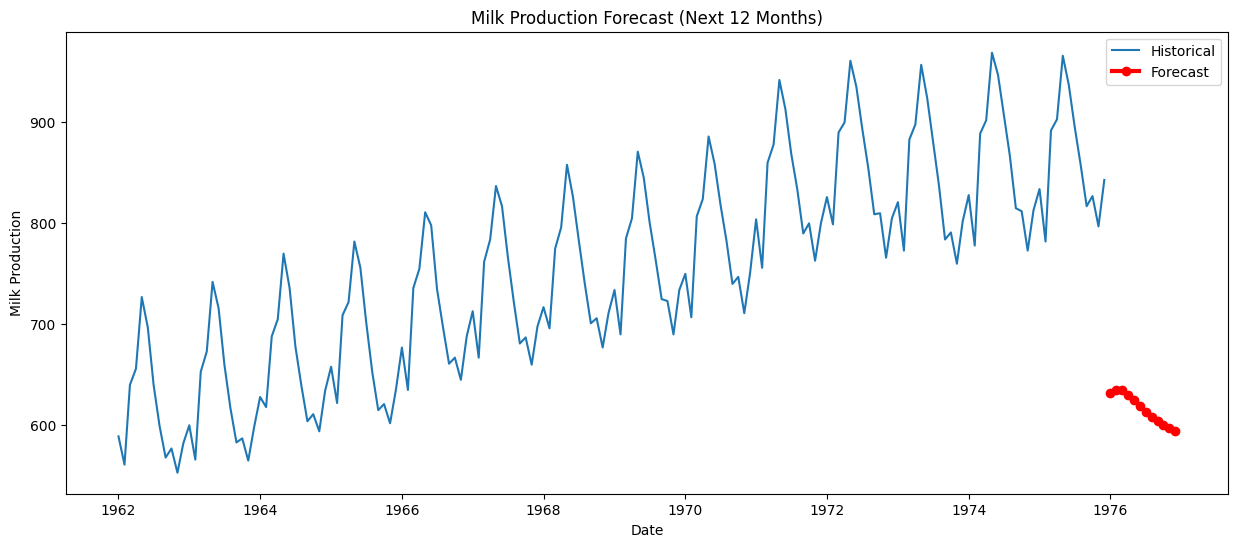

In [65]:
plt.figure(figsize=(15,6))

plt.plot(df.index,
         df['Milk Production'],
         label='Historical')

plt.plot(future_dates,
         future_predictions,
         color='red',
         linewidth=3,
         marker='o',
         label='Forecast')

plt.title("Milk Production Forecast (Next 12 Months)")
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

forecast table

In [66]:
forecast_df = pd.DataFrame({

    "Month":future_dates,

    "Predicted Milk Production":future_predictions.flatten()

})

forecast_df

,Month,Predicted Milk Production
0,1976-01-01,632.388794
1,1976-02-01,635.330383
2,1976-03-01,634.590027
3,1976-04-01,630.388916
4,1976-05-01,625.096985
5,1976-06-01,618.888916
6,1976-07-01,613.187073
7,1976-08-01,608.227905
8,1976-09-01,603.994385
9,1976-10-01,600.490906


business insights and recommandations

In [67]:
print("Business Insights")
print("- Seasonal patterns are observed in milk production.")
print("- The selected model provides accurate future forecasts.")
print("- Forecasts help optimize inventory and resource planning.")
print("- High-production months require additional storage and logistics.")
print("- Low-production months are suitable for maintenance activities.")
print("- Forecasting improves supply chain and financial planning.")

Business Insights
- Seasonal patterns are observed in milk production.
- The selected model provides accurate future forecasts.
- Forecasts help optimize inventory and resource planning.
- High-production months require additional storage and logistics.
- Low-production months are suitable for maintenance activities.
- Forecasting improves supply chain and financial planning.


create data frame

In [68]:
insights = pd.DataFrame({
    "Business Insights": [
        "Seasonal production pattern observed.",
        "Best-performing model selected based on RMSE, MAE, and MAPE.",
        "Forecasts support inventory management.",
        "Resource allocation can be optimized.",
        "Production planning becomes more efficient.",
        "Forecasting helps reduce operational costs."
    ]
})

insights

,Business Insights
0,Seasonal production pattern observed.
1,"Best-performing model selected based on RMSE, ..."
2,Forecasts support inventory management.
3,Resource allocation can be optimized.
4,Production planning becomes more efficient.
5,Forecasting helps reduce operational costs.
